# FlashAttention never builds the 34 GB score matrix

Companion notebook for the article. Run all cells to reproduce every number and the figure. Needs only NumPy and matplotlib.

From [*Math for ML Engineers: From Backprop to RLHF*](https://mikaelyemane.github.io/ml-math-code/) by Mikael Yemane.

## No n × n array anywhere

In [1]:
import numpy as np

def flash_attention(Q, K, V, block_q=64, block_k=64):
    """Tiled forward pass with online softmax. Never allocates an (n, n) array."""
    n, d = Q.shape
    scale = 1.0 / np.sqrt(d)
    O = np.zeros((n, d), dtype=Q.dtype)

    for i in range(0, n, block_q):
        qi = Q[i:i + block_q]                            # (Bq, d)
        rows = qi.shape[0]

        # Running softmax state for this row block.
        m = np.full((rows, 1), -np.inf, dtype=Q.dtype)   # running row max
        l = np.zeros((rows, 1), dtype=Q.dtype)           # running denominator
        acc = np.zeros((rows, d), dtype=Q.dtype)         # running numerator

        for j in range(0, n, block_k):
            kj = K[j:j + block_k]                        # (Bk, d)
            vj = V[j:j + block_k]                        # (Bk, d)

            s = (qi @ kj.T) * scale                      # (Bq, Bk)  <-- only this
            m_new = np.maximum(m, s.max(axis=-1, keepdims=True))

            # Rescale the state carried from previous blocks onto the new max.
            rescale = np.exp(m - m_new)
            p = np.exp(s - m_new)                        # (Bq, Bk)

            l = rescale * l + p.sum(axis=-1, keepdims=True)
            acc = rescale * acc + p @ vj
            m = m_new

        O[i:i + block_q] = acc / l

    return O

In [2]:
rng = np.random.default_rng(0)
for n in (256, 1000):
    Q, K, V = (rng.standard_normal((n, 64)) for _ in range(3))
    S = Q @ K.T / 8.0
    P = np.exp(S - S.max(-1, keepdims=True)); P /= P.sum(-1, keepdims=True)
    Q32, K32, V32 = (a.astype(np.float32) for a in (Q, K, V))
    for bq, bk in ((16, 256), (64, 64), (256, 256)):
        err = np.abs(flash_attention(Q, K, V, bq, bk) - P @ V).max()
        e32 = np.abs(flash_attention(Q32, K32, V32, bq, bk) - P @ V).max()
        print(f"n={n:5d} blocks {bq}x{bk}: max error vs reference {err:.1e}, float32 run {e32:.1e}")

n=  256 blocks 16x256: max error vs reference 8.9e-16, float32 run 2.7e-07
n=  256 blocks 64x64: max error vs reference 6.1e-16, float32 run 2.7e-07
n=  256 blocks 256x256: max error vs reference 8.9e-16, float32 run 2.7e-07
n= 1000 blocks 16x256: max error vs reference 3.6e-16, float32 run 2.3e-07
n= 1000 blocks 64x64: max error vs reference 3.5e-16, float32 run 2.3e-07
n= 1000 blocks 256x256: max error vs reference 3.6e-16, float32 run 2.3e-07


## The backward pass needs one number per row

In [3]:
rng = np.random.default_rng(1)
s, V = 3 * rng.standard_normal(10), rng.standard_normal((10, 4))   # one row of scores
m, l = -np.inf, 0.0
for blk in np.split(s, [3, 7]):                       # blocks of 3, 4 and 3 scores
    m_new = max(m, blk.max())
    l = np.exp(m - m_new) * l + np.exp(blk - m_new).sum()
    m = m_new
L = m + np.log(l)                                     # the one number the backward keeps
P = np.exp(s - s.max()) / np.exp(s - s.max()).sum()   # two-pass softmax
print(f"m vs max: {abs(m - s.max()):.0e}, exp(s - L) vs softmax: {np.abs(np.exp(s - L) - P).max():.1e}")

dO = rng.standard_normal(4)                           # gradient flowing into this row's output
O, dP = P @ V, V @ dO
dS_full = (np.diag(P) - np.outer(P, P)) @ dP          # full n x n softmax Jacobian
dS_tile = P * (dP - O @ dO)                           # D = O·dO, one scalar per row
print(f"dS from D vs full Jacobian: {np.abs(dS_tile - dS_full).max():.1e}")

m vs max: 0e+00, exp(s - L) vs softmax: 2.8e-17
dS from D vs full Jacobian: 1.4e-17


## Reproduce the numbers quoted in the text

In [4]:
rng = np.random.default_rng(0)
for n in (256, 1000):
    Q, K, V = (rng.standard_normal((n, 64)) for _ in range(3))
    S = Q @ K.T / 8.0
    P = np.exp(S - S.max(-1, keepdims=True)); P /= P.sum(-1, keepdims=True)
    Q32, K32, V32 = (a.astype(np.float32) for a in (Q, K, V))
    for bq, bk in ((16, 256), (64, 64), (256, 256)):
        err = np.abs(flash_attention(Q, K, V, bq, bk) - P @ V).max()
        e32 = np.abs(flash_attention(Q32, K32, V32, bq, bk) - P @ V).max()
        print(f"n={n:5d} blocks {bq}x{bk}: max error vs reference {err:.1e}, float32 run {e32:.1e}")

n=  256 blocks 16x256: max error vs reference 8.9e-16, float32 run 2.7e-07
n=  256 blocks 64x64: max error vs reference 6.1e-16, float32 run 2.7e-07
n=  256 blocks 256x256: max error vs reference 8.9e-16, float32 run 2.7e-07
n= 1000 blocks 16x256: max error vs reference 3.6e-16, float32 run 2.3e-07


n= 1000 blocks 64x64: max error vs reference 3.5e-16, float32 run 2.3e-07
n= 1000 blocks 256x256: max error vs reference 3.6e-16, float32 run 2.3e-07


## The figure

In [5]:
#@title Shared figure style (run this cell; the code can stay hidden)
"""Shared figure style for the article series.

Static PNGs for Medium/Substack (light page), 1600 x 900 px at 200 dpi.
Palette: validated categorical slots 1-3 (all-pairs pass, light mode).
Slot 3 (aqua) is below 3:1 contrast on the surface, so every series is
direct-labeled; identity never rests on color alone.
"""
import matplotlib

import matplotlib.pyplot as plt  # noqa: E402

SURFACE = "#ffffff"
INK = "#0b0b0b"          # primary text
INK_2 = "#52514e"        # secondary text, axis labels
MUTED = "#8a8985"        # tick labels, annotations
GRID = "#e8e7e3"         # recessive grid
NEUTRAL = "#b9b8b3"      # de-emphasized series / reference lines

S1, S2, S3 = "#2a78d6", "#eb6834", "#1baf7a"   # blue, orange, aqua
SERIES = [S1, S2, S3]

FIG_W, FIG_H, DPI = 8.0, 4.5, 200


def setup():
    plt.rcParams.update({
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "font.size": 11,
        "font.family": "DejaVu Sans",
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_2,
        "axes.labelsize": 11,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlecolor": INK,
        "axes.titlelocation": "left",
        "axes.titlepad": 22,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "lines.linewidth": 2.0,
        "lines.markersize": 6,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "legend.labelcolor": INK_2,
    })


def fig(nrows=1, ncols=1, **kw):
    setup()
    return plt.subplots(nrows, ncols, figsize=(FIG_W, FIG_H), dpi=DPI, **kw)


def subtitle(ax, text):
    """Units / one-line context under the title, in secondary ink."""
    ax.text(0, 1.02, text, transform=ax.transAxes, color=INK_2,
            fontsize=10, va="bottom", ha="left")


def label_end(ax, x, y, text, color, dx=4, dy=0):
    """Direct label at a line's end, in text ink with a color key dot."""
    ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points",
                color=INK, fontsize=10, va="center", ha="left")


def save(f, path):
    f.tight_layout()
    f.savefig(path, dpi=DPI)
    print("wrote", path)

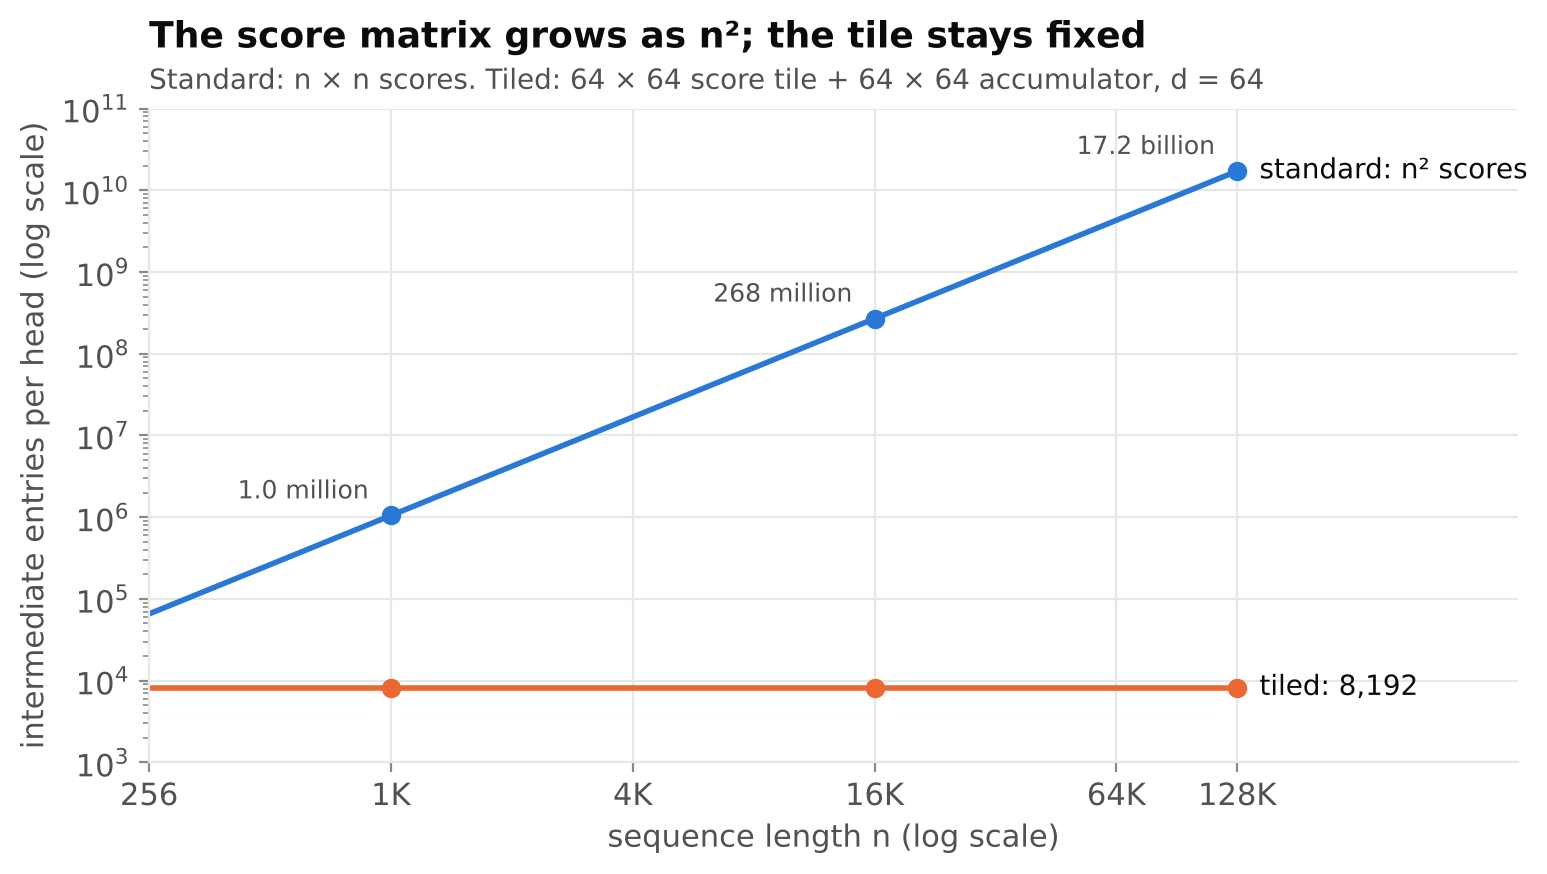

In [6]:
#@title The figure
import contextlib, io
__file__ = 'figure.py'  # the PNG is saved next to the notebook
with contextlib.redirect_stdout(io.StringIO()):  # keep the output to the chart
    import pathlib
    import numpy as np

    B, d = 64, 64
    tile = B * B + B * d                         # score tile + accumulator = 8,192
    n = np.logspace(np.log10(256), np.log10(131072), 200)
    pts = np.array([1024, 16384, 131072])

    f, ax = fig()
    ax.plot(n, n**2, color=S1)
    ax.plot(n, np.full_like(n, tile), color=S2)
    ax.plot(pts, pts.astype(float)**2, "o", color=S1, ms=6)
    ax.plot(pts, np.full(3, tile), "o", color=S2, ms=6)
    for p, txt in zip(pts, ("1.0 million", "268 million", "17.2 billion")):
        ax.annotate(txt, (p, float(p)**2), xytext=(-8, 4), textcoords="offset points",
                    color=INK_2, fontsize=9, ha="right", va="bottom")
    label_end(ax, n[-1], n[-1]**2, "standard: n² scores", S1, dx=8)
    label_end(ax, n[-1], tile, "tiled: 8,192", S2, dx=8)
    ax.set_xscale("log", base=2); ax.set_yscale("log")
    ax.set_xticks([256, 1024, 4096, 16384, 65536, 131072])
    ax.set_xticklabels(["256", "1K", "4K", "16K", "64K", "128K"])
    ax.set_xlim(256, 131072 * 5)
    ax.set_ylim(1e3, 1e11)
    ax.set_xlabel("sequence length n (log scale)")
    ax.set_ylabel("intermediate entries per head (log scale)")
    ax.set_title("The score matrix grows as n²; the tile stays fixed")
    subtitle(ax, "Standard: n × n scores. Tiled: 64 × 64 score tile + 64 × 64 accumulator, d = 64")
    save(f, pathlib.Path(__file__).parent / "05-attention-memory.png")
    print(tile, [p**2 for p in pts])
import matplotlib.pyplot as plt
plt.show()